##

##

In [1]:
# loading packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as ss
import shap

c:\Anaconda\Anaconda3\envs\research_env_v2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# machine learning regression
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_validate, cross_val_score, StratifiedKFold, KFold, RandomizedSearchCV
from sklearn.preprocessing import PolynomialFeatures , MinMaxScaler
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, RidgeCV, Lasso, LassoCV, ElasticNet, BayesianRidge 
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score  , mean_absolute_percentage_error
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.utils import shuffle
from sklearn.cluster import KMeans
from sklearn.base import clone

from xgboost import XGBRegressor , XGBClassifier
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb

In [3]:
# Machine Leraning Classify
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV

In [4]:
#=========================================================
#  Load dataset and checking nan
#=========================================================

df_original = pd.read_csv("C:\\Github\\Coral_Bleaching_Predictor\\Data\\dataset.csv" , na_values=['nd']) # old data
print(f"total number of rows and columns in the dataset: {len(df_original.columns) + 1} columns, {len(df_original) + 1} rows")


# Grouping years into decodes
def Grouping_date_to_year(df):
    #Changing date to year
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df['Year'] = df['Date'].dt.year # New columns with only year 
    
    year_counts = df.groupby(['Year']).size()
    print(year_counts)
    

    return df

df_Grouping_year = Grouping_date_to_year(df_original)

# Check NAN Data and by what percentage
def nan_check(data):
    total = data.isnull().sum().sort_values(ascending=False)
    percent_1 = data.isnull().sum()/data.isnull().count()*100
    percent_2 = (np.round(percent_1, 1)).sort_values(ascending=False)
    missing_data = pd.concat([total, percent_2], axis=1, keys=['Total', '%'])
    return missing_data

Missing  = nan_check(df_Grouping_year)
Missing

total number of rows and columns in the dataset: 49 columns, 9666 rows
Year
1998      5
2000      2
2001      3
2002     63
2003    599
2004    731
2005    700
2006    850
2007    643
2008    692
2009    721
2010    538
2011    533
2012    563
2013    626
2014    600
2015    615
2016    619
2017    562
dtype: int64


,Total,%
City_Town_3,8728,90.3
City_Town_2,4943,51.1
City_Town,437,4.5
State_Island_Province,36,0.4
SSTA_Minimum,12,0.1
SSTA_FrequencyMax,5,0.1
SSTA_Standard_Deviation,5,0.1
TSA_Maximum,5,0.1
SSTA_Maximum,5,0.1
SSTA_Frequency,5,0.1


In [5]:
#=================================================
# Function analysis variable for Cleaning data
#=================================================
def Columns_percent_missing(df,df_dtype, col):
    
    count_less = 0
    count_more = 0
    Index_more = []
    Index_less = []
    for_drop = []
    type_object = []
    type_number = []
    for idx, value in df[col].items():
        if value >= 0.4:
            count_more += 1
            Index_more.append(idx)
            for_drop.append(idx)
        elif value < 0.4:
            count_less += 1
            Index_less.append(idx)
            
    for i in df_dtype.columns:
        if df_dtype[i].dtype == 'object':
            type_object.append(i)
        else:
            type_number.append(i)

    print("\n")
    print(f"more than 0.4% : {count_more}")
    print(f"less than 0.4% : {count_less}")
    print(f"Name_of_moreNAN : {len(Index_more)} attribuue : {Index_more}")
    print(f"Name_of_lessNAN : {len(Index_less)} attribuue : {Index_less}")
    print(f"for_drop : {len(for_drop)} attribuue : {for_drop}")
    print(f"object type : {len(type_object)} attribue : {type_object}")
    print(f"number type : {len(type_number)} attribue : {type_number}")

    return for_drop , type_object
    
columns_drop, col_object = Columns_percent_missing(Missing, df_original, '%')
print("="*80)
print(">>>>>>>  Missing values more than 0.4% : Delete <<<<<<<<")
print("="*80)



more than 0.4% : 4
less than 0.4% : 45
Name_of_moreNAN : 4 attribuue : ['City_Town_3', 'City_Town_2', 'City_Town', 'State_Island_Province']
Name_of_lessNAN : 45 attribuue : ['SSTA_Minimum', 'SSTA_FrequencyMax', 'SSTA_Standard_Deviation', 'TSA_Maximum', 'SSTA_Maximum', 'SSTA_Frequency', 'SSTA_Frequency_Standard_Deviation', 'SSTA_Mean', 'SSTA_FrequencyMean', 'Temperature_Kelvin_Standard_Deviation', 'SSTA_DHW', 'SSTA_DHW_Standard_Deviation', 'SSTA_DHWMax', 'SSTA_DHWMean', 'TSA', 'SSTA', 'Temperature_Minimum', 'Temperature_Maximum', 'TSA_Minimum', 'Temperature_Mean', 'Temperature_Kelvin', 'TSA_Mean', 'TSA_Frequency', 'TSA_Frequency_Standard_Deviation', 'TSA_FrequencyMax', 'TSA_FrequencyMean', 'TSA_DHW', 'TSA_DHW_Standard_Deviation', 'TSA_DHWMax', 'TSA_DHWMean', 'TSA_Standard_Deviation', 'Windspeed', 'ClimSST', 'ID', 'Latitude_Degrees', 'Average_Bleaching', 'Depth', 'Date2', 'Date', 'Country_Name', 'Ecoregion', 'Realm', 'Ocean', 'Longitude_Degrees', 'Year']
for_drop : 4 attribuue : ['City

In [6]:
#=========================================
# Cleaning data
#=========================================
def Clean_data_paper(df, col_object, col_dont_need):
    
    # using data from 2003 to 2020
    df = df[df['Year'] > 2002]

    # Taking only SSTA > 0
    df['SSTA'] = pd.to_numeric(df['SSTA'], errors='coerce') # แปลง ค่าของ SSTA เป็นตัวเลข เเละจัดการกับค่าที่ไม่สามารถเเปลงได้ด้วยการใช้ 'coerce' ซึ่งจะทำให้ค่าที่แปลงไม่ได้กลายเป็น NaN
    df = df[df['SSTA'] > 0] # เลือกเฉพาะคที่มีค่า SSTA มากกว่า 0 เเละ NaN จะถูกละทิ้งไปโดยอัตโนมัติ
    
    df_object = df.drop(columns=col_object) # ลบคอลัมน์ที่เป็น Object ออกเเละค่าที่ไม่จำเป็นออกไป
    df_dont_need = df_object.drop(columns=col_dont_need) # ลบคอลัมน์ที่ไม่จำเป็นออกไป

    df = df_dont_need.rename(columns={"Depth": "Depth_m", "Average_Bleaching": "Percent_Bleaching"}) # เปลี่ยนชื่อคอลัมน์ให้สั้นลง เเละเจข้าใจง่ายขึ้น

    #Transforming column datatypes
    df['ClimSST'] = pd.to_numeric(df['ClimSST'],errors='coerce')
    df['Percent_Bleaching'] = pd.to_numeric(df['Percent_Bleaching'],errors='coerce')
    
    return df

col_dont_need = ['ID', 'Date', 'Date2', 'SSTA_Mean']
df_Clean_already = Clean_data_paper(df_Grouping_year, col_object, col_dont_need)
df_Clean_already = df_Clean_already.fillna(method='ffill')
print("="*200)
print(f"{col_object} >>>>> {col_dont_need} : {len(col_object) + len(col_dont_need)} >>>>>>>> {len(df_original.columns) - len(col_object) - len(col_dont_need)}")
print(f"total number of rows and columns in the dataset: {len(df_Clean_already.columns)} columns, {len(df_Clean_already)} rows")
print("มีการเพิ่มคอลัมน์ Year ขึ้นมาเพื่อนำมาใช้ในการจัดกลุ่มข้อมูลตามปี")
print("="*200)

['Ocean', 'Realm', 'Ecoregion', 'Country_Name', 'State_Island_Province', 'City_Town', 'City_Town_2', 'City_Town_3'] >>>>> ['ID', 'Date', 'Date2', 'SSTA_Mean'] : 12 >>>>>>>> 37
total number of rows and columns in the dataset: 37 columns, 6112 rows
มีการเพิ่มคอลัมน์ Year ขึ้นมาเพื่อนำมาใช้ในการจัดกลุ่มข้อมูลตามปี


C:\Users\superuser\AppData\Local\Temp\ipykernel_10224\4233094419.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['SSTA'] = pd.to_numeric(df['SSTA'], errors='coerce') # แปลง ค่าของ SSTA เป็นตัวเลข เเละจัดการกับค่าที่ไม่สามารถเเปลงได้ด้วยการใช้ 'coerce' ซึ่งจะทำให้ค่าที่แปลงไม่ได้กลายเป็น NaN
C:\Users\superuser\AppData\Local\Temp\ipykernel_10224\4233094419.py:26: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_Clean_already = df_Clean_already.fillna(method='ffill')


## ***ตัวแปรที่เก็บ data เเละพร้อมใช้งานสำหรับการนำไปวิเคราะห์ df_Clean_already***

##

##

### - **Exploratory Data Analysis**

In [7]:
#===============================================
# Total Function 
#===============================================

def Plotting_feature_target(df,col_feature, col_target='Percent_Bleaching'):
    
    X = df[col_feature]
    y = df[col_target]
    
    plt.figure(figsize=(6,4))
    plt.scatter(X, y, color='white', edgecolor='black', alpha=0.7)
    plt.xlabel(col_feature)
    plt.ylabel(col_target)
    plt.title(f'{col_feature} vs {col_target}')
    plt.show()
    
    
def Create_Feature_from_equetion(df, O1, O2,f):
    
    from scipy.stats import pearsonr, spearmanr

    transforms = {
        'feature_En is '+ f: df[f],
        'original1 is ' + O1: df[O1],
        'original2 is ' + O2: df[O2]
        
    }

    for name, col in transforms.items():
        r, _ = spearmanr(col, df['Percent_Bleaching'])
        print(f"{name}: Spearman r = {r:.4f}")
        
    print("="*50)
    
    for name, col in transforms.items():
        r, _ = pearsonr(col, df['Percent_Bleaching'])
        print(f"{name}: Pearsonr r = {r:.4f}")

In [8]:
df_exploratory = df_Clean_already.copy()

In [9]:
# 1. สร้างคอลัมน์ 'Bin' เพื่อช่วยในการแบ่ง (Stratification)
# แบ่งเป็น 0 (ไม่ฟอก) กับ 1 (ฟอกขาว)
df_exploratory['Classify'] = (df_exploratory['Percent_Bleaching'] >= 1).astype(int)
print(df_exploratory[['Classify']].value_counts())
print('='*40)
print(f"Original feature : {len(df_Clean_already.columns)} ---> become {len(df_exploratory.columns)}")

Classify
0           4513
1           1599
Name: count, dtype: int64
Original feature : 37 ---> become 38


In [10]:
#===============================
# >= 1 is Bleaching
#===============================
Bleaching = df_exploratory[df_exploratory['Classify'] == 1]

In [11]:
# ตรวจก่อนว่ามี Depth_m = 0 ไหม
print(Bleaching['Depth_m'].describe())
print(f"Depth_m = 0: {(Bleaching['Depth_m'] == 0).sum()} rows")
print(f"Depth_m < 0: {(Bleaching['Depth_m'] < 0).sum()} rows")

# สร้าง feature พร้อม guard
epsilon = 1e-9  # ป้องกัน division by zero

Bleaching['SSTA_DHW_TSA_DHW']  = (
    Bleaching['SSTA_DHW'] / np.sqrt(Bleaching['Depth_m'])
)

# ตรวจ NaN / inf หลังสร้าง
print(Bleaching[['SSTA_DHW_TSA_DHW']].isin([np.inf, -np.inf]).sum())
print(Bleaching[['SSTA_DHW_TSA_DHW']].isna().sum())

count    1599.000000
mean        6.737336
std         3.630022
min         0.100000
25%         4.000000
50%         6.000000
75%        10.000000
max        21.700000
Name: Depth_m, dtype: float64
Depth_m = 0: 0 rows
Depth_m < 0: 0 rows
SSTA_DHW_TSA_DHW    0
dtype: int64
SSTA_DHW_TSA_DHW    0
dtype: int64


C:\Users\superuser\AppData\Local\Temp\ipykernel_10224\1023250813.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Bleaching['SSTA_DHW_TSA_DHW']  = (


In [12]:
Create_Feature_from_equetion(Bleaching, 'SSTA_DHW','Depth_m', 'SSTA_DHW_TSA_DHW')

feature_En is SSTA_DHW_TSA_DHW: Spearman r = 0.1665
original1 is SSTA_DHW: Spearman r = 0.1744
original2 is Depth_m: Spearman r = -0.0193
feature_En is SSTA_DHW_TSA_DHW: Pearsonr r = 0.1933
original1 is SSTA_DHW: Pearsonr r = 0.2526
original2 is Depth_m: Pearsonr r = 0.0092


In [13]:
Bleaching[['Windspeed']].describe()

,Windspeed
count,1599.000000
mean,4.886804
std,2.023101
min,0.000000
25%,3.000000
50%,5.000000
75%,6.000000
max,14.000000


##

##

### **Principle component Analysis (PCA)**
- feature follow paper : ClimSST , Depth_m , Latitude , Longitude , SSTA
- feature Additive : SSTA_DHW , Temperature_Kelvin

In [14]:
df_principal = df_Clean_already.copy()

In [15]:
def Grouping_data(df, col_groupby, name_new_col, cols_keep=None):
    df_new = df.copy()
    df_new = df_new[col_groupby]
    print(f"Groupby name is : {name_new_col}")
    
    return df_new

In [16]:
col_paper = [
                'Latitude_Degrees',
                'Longitude_Degrees',
                'ClimSST',
                'Depth_m',
                'SSTA'
            ]
df_paper_groupby = Grouping_data(df_principal, col_paper, 'paper_groupby')
#-----------------------------------------------------------------------------------------------------
col_Additive = [
                    'SSTA_DHW',
                    'Temperature_Kelvin'
               ]
df_Additive_groupby = Grouping_data(df_Clean_already, col_Additive, 'Additive_groupby')

#-----------------------------------------------------------------------------------------------------
col_Other = df_Clean_already.drop(columns=col_paper + col_Additive + ['Percent_Bleaching']).columns.tolist()
df_Other_groupby = Grouping_data(df_principal, col_Other, 'Other_groupby')

Groupby name is : paper_groupby
Groupby name is : Additive_groupby
Groupby name is : Other_groupby


In [17]:
print("-"*50)
print(df_paper_groupby.isnull().sum())
print("-" * 50)
print(df_Additive_groupby.isnull().sum())
print("-" * 50)
print(df_Other_groupby.isnull().sum())


--------------------------------------------------
Latitude_Degrees     0
Longitude_Degrees    0
ClimSST              0
Depth_m              0
SSTA                 0
dtype: int64
--------------------------------------------------
SSTA_DHW              0
Temperature_Kelvin    0
dtype: int64
--------------------------------------------------
Temperature_Mean                         0
Temperature_Minimum                      0
Temperature_Maximum                      0
Temperature_Kelvin_Standard_Deviation    0
Windspeed                                0
SSTA_Standard_Deviation                  0
SSTA_Minimum                             0
SSTA_Maximum                             0
SSTA_Frequency                           0
SSTA_Frequency_Standard_Deviation        0
SSTA_FrequencyMax                        0
SSTA_FrequencyMean                       0
SSTA_DHW_Standard_Deviation              0
SSTA_DHWMax                              0
SSTA_DHWMean                             0
TSA          

In [18]:
len(df_Other_groupby.columns) + len(df_paper_groupby.columns) + len(df_Additive_groupby.columns)

36

In [19]:
print(len(df_Other_groupby.columns))
print(len(df_paper_groupby.columns))
print(len(df_Additive_groupby.columns))

29
5
2


In [20]:
def transform_pca_to_dataframe(pca_result, prefix):

    n_components = pca_result.shape[1]

    column_names = [
        f'{prefix}_PC{i+1}'
        for i in range(n_components)
    ]

    return pd.DataFrame(
        pca_result,
        columns=column_names
    )



A = {'paper': df_paper_groupby, 'Additive' : df_Additive_groupby, 'Other' : df_Other_groupby}

def PCA_algorithm(list_member, keys=None, threshold=0.95):

    results = {}
    scaler_pca = StandardScaler()

    if keys is None:
        keys = list_member.keys()

    for name in keys:

        df = list_member[name]

        # Scale
        df_makepca = scaler_pca.fit_transform(df)

        # หา optimal components
        pca_temp = PCA(n_components=threshold)
        pca_temp.fit(df_makepca)

        cumulative_variance = np.cumsum(
            pca_temp.explained_variance_ratio_
        )

        optimal_components = (
            np.argmax(cumulative_variance >= threshold) + 1
        )

        # PCA จริง
        pca_model = PCA(n_components=optimal_components)

        pca_result = pca_model.fit_transform(df_makepca)

        # DataFrame
        df_pca = transform_pca_to_dataframe(
            pca_result,
            prefix=name
        )

        results[name] = df_pca

        print(f"=== {name} === optimal components: {optimal_components}")
        print(df_pca)

    return results

results = PCA_algorithm(A, keys=['Other'])

=== Other === optimal components: 12
      Other_PC1  Other_PC2  Other_PC3  Other_PC4  Other_PC5  Other_PC6  \
0      1.300948  -2.589686  -1.381836  -1.514556   0.571404   0.370419   
1      1.300948  -2.589686  -1.381836  -1.514556   0.571404   0.370419   
2      0.140914  -2.744137  -1.160624  -1.357529   0.263178   0.039602   
3      0.163821  -2.872225  -1.174130  -0.697434   0.755801   0.235392   
4      1.987450  -3.285895  -0.816472  -1.984283  -0.105507   1.602679   
...         ...        ...        ...        ...        ...        ...   
6107   5.165958  -6.030551   0.275126   1.206491   0.736922  -1.147283   
6108   7.422656  -5.389550   1.995904   2.154085   0.646855  -1.141075   
6109   2.403828  -1.454664   2.298108   5.086208   1.239894   1.748429   
6110   0.354952  -1.501565   0.992701   0.798665   0.598970  -0.524530   
6111   0.361905  -1.505484   0.996071   0.796539   0.606778  -0.532861   

      Other_PC7  Other_PC8  Other_PC9  Other_PC10  Other_PC11  Other_PC12 

In [21]:
df_all_pca = pd.concat(results.values(), axis=1)

In [22]:
df_all_pca

,Other_PC1,Other_PC2,Other_PC3,Other_PC4,Other_PC5,Other_PC6,Other_PC7,Other_PC8,Other_PC9,Other_PC10,Other_PC11,Other_PC12
0,1.300948,-2.589686,-1.381836,-1.514556,0.571404,0.370419,0.700243,-1.263148,0.146167,0.280167,0.961962,0.833592
1,1.300948,-2.589686,-1.381836,-1.514556,0.571404,0.370419,0.700243,-1.263148,0.146167,0.280167,0.961962,0.833592
2,0.140914,-2.744137,-1.160624,-1.357529,0.263178,0.039602,0.273282,-0.932679,0.987954,0.890242,0.878635,1.025465
3,0.163821,-2.872225,-1.174130,-0.697434,0.755801,0.235392,0.579093,-1.025484,0.835186,0.750136,1.068144,0.584368
4,1.987450,-3.285895,-0.816472,-1.984283,-0.105507,1.602679,-1.989509,-0.162516,-0.312848,1.465404,-0.168288,-0.262139
...,...,...,...,...,...,...,...,...,...,...,...,...
6107,5.165958,-6.030551,0.275126,1.206491,0.736922,-1.147283,0.715728,-0.439532,-2.128102,0.604207,-0.606528,1.948344
6108,7.422656,-5.389550,1.995904,2.154085,0.646855,-1.141075,0.558393,-0.409708,-1.192706,-0.320604,-0.970303,0.423104
6109,2.403828,-1.454664,2.298108,5.086208,1.239894,1.748429,0.325407,-0.313200,1.066402,1.135951,-0.018644,-0.364640
6110,0.354952,-1.501565,0.992701,0.798665,0.598970,-0.524530,-0.563483,1.106473,-1.249733,-0.696587,0.372709,1.132852


In [23]:
df_paper_groupby

,Latitude_Degrees,Longitude_Degrees,ClimSST,Depth_m,SSTA
0,-20.899833,149.407722,297.78,4.0,1.320000
1,-20.893056,149.421000,297.78,5.0,1.320000
2,-20.745806,149.472056,298.17,6.0,0.870000
3,-20.737694,149.464944,298.21,5.0,1.070000
4,-20.259361,148.814583,296.48,2.0,1.760000
...,...,...,...,...,...
9641,20.738889,107.058333,262.15,3.2,0.033333
9646,20.845833,107.177778,299.80,3.0,0.510000
9649,12.601722,53.817306,301.40,6.0,0.050000
9663,15.701611,42.391806,304.39,9.0,0.110000


In [24]:
df_Additive_groupby   

,SSTA_DHW,Temperature_Kelvin
0,3.960000,301.670
1,3.960000,301.670
2,2.680000,301.380
3,3.650000,301.560
4,3.840000,296.380
...,...,...
9641,2.378333,302.955
9646,0.000000,302.300
9649,0.000000,302.670
9663,2.250000,303.890


##

##

# 🌲 Modeling

## Tree-Based Models

### Models Used
- 🌳 Random Forest
- 🚀 XGBoost
- ⚡ LightGBM
- 🐱 CatBoost

### Tasks
#### Classification
- Predict categorical outcomes
- Example: Bleaching / Non-Bleaching

#### Regression
- Predict continuous values
- Example: Percent Bleaching

#### Data for techniqui and design aigorithm
- data for PCA
- data following paper
- data additive

In [25]:
def PLOTING_RESULT_ML(model, X_test, y_test, cl, name):

    y_pred = model.predict(X_test).ravel()
    y_test = np.array(y_test).ravel()

    plt.figure(figsize=(10, 6))

    sns.scatterplot(
        x=y_test,
        y=y_pred,
        alpha=0.5,
        color=cl,
        edgecolor='k'
    )

    # ideal line
    plt.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        color='red',
        linestyle='--',
        lw=2
    )

    plt.title(f'Actual vs Predicted Percent Bleaching : {name}')
    plt.xlabel('Actual Bleaching (%)')
    plt.ylabel('Predicted Bleaching (%)')

    plt.grid(True, linestyle=':', alpha=0.6)

    plt.show()

#--------------------------------------------------------------------------------------------------------------------------------------------#

def Metric_result(model, X_train, X_test, y_train, y_test):

    y_train = np.array(y_train).ravel()
    y_test = np.array(y_test).ravel()

    print(f"Score on training data: {(model.score(X_train, y_train)):.2f}")

    pred = model.predict(X_test).ravel()

    print("-" * 30)

    test_mse = mean_squared_error(y_test, pred)
    print(f"Test MSE: {test_mse:.2f}")

    print("-" * 30)

    test_rmse = np.sqrt(test_mse)
    print(f"Test RMSE : {test_rmse:.2f}")

    print("-" * 30)

    test_r2 = r2_score(y_test, pred)
    print(f"Test R2 Score : {test_r2:.2f}")

    print("-" * 30)

    test_mae = mean_absolute_error(y_test, pred)
    print(f"Mean Absolute Error : {test_mae:.2f}")

    print("-" * 30)

    test_mape = mean_absolute_percentage_error(y_test, pred) # Mean_Absolute_Percentage_Error
    print(f"Mean Absolute Percentage Error : {test_mape:.2f}")
    print("-" * 30)
    
#=========================================================================================================================================#

#=========================================================================================================================================================#
def feature_importance(model, feature_names):
    
    importance = model.feature_importances_
    feature_names_importance = feature_names.columns
    
    df_importance = pd.DataFrame({
        'feature' : feature_names_importance,
        'importance' : importance
    }).sort_values(by='importance', ascending=False)
    
    return df_importance

In [26]:
f = [df_all_pca, df_paper_groupby, df_Additive_groupby, df_principal[['Percent_Bleaching']]]
t = df_principal[['Percent_Bleaching']]

def set_feature_and_target_formethod(list_X):
    
    feature = pd.concat(
        [df.reset_index(drop=True) for df in list_X],
        axis=1
    )
    
    feature['Classify'] = (feature['Percent_Bleaching'] >= 1).astype(int)
    print(feature[['Classify']].value_counts())
    print("="*98)
    print(f"ในนี้รวม feature สำหรับ training ทั้งหมด {len(feature.columns)} , รวมทั้ง percent_bleaching เเละ Classify สำหรับ stage 1")
    print("="*98)
    
    return feature 

feature_method = set_feature_and_target_formethod(f)

Classify
0           4513
1           1599
Name: count, dtype: int64
ในนี้รวม feature สำหรับ training ทั้งหมด 21 , รวมทั้ง percent_bleaching เเละ Classify สำหรับ stage 1


In [27]:
feature_method

,Other_PC1,Other_PC2,Other_PC3,Other_PC4,Other_PC5,Other_PC6,Other_PC7,Other_PC8,Other_PC9,Other_PC10,...,Other_PC12,Latitude_Degrees,Longitude_Degrees,ClimSST,Depth_m,SSTA,SSTA_DHW,Temperature_Kelvin,Percent_Bleaching,Classify
0,1.300948,-2.589686,-1.381836,-1.514556,0.571404,0.370419,0.700243,-1.263148,0.146167,0.280167,...,0.833592,-20.899833,149.407722,297.78,4.0,1.320000,3.960000,301.670,6.25,1
1,1.300948,-2.589686,-1.381836,-1.514556,0.571404,0.370419,0.700243,-1.263148,0.146167,0.280167,...,0.833592,-20.893056,149.421000,297.78,5.0,1.320000,3.960000,301.670,8.75,1
2,0.140914,-2.744137,-1.160624,-1.357529,0.263178,0.039602,0.273282,-0.932679,0.987954,0.890242,...,1.025465,-20.745806,149.472056,298.17,6.0,0.870000,2.680000,301.380,11.25,1
3,0.163821,-2.872225,-1.174130,-0.697434,0.755801,0.235392,0.579093,-1.025484,0.835186,0.750136,...,0.584368,-20.737694,149.464944,298.21,5.0,1.070000,3.650000,301.560,25.00,1
4,1.987450,-3.285895,-0.816472,-1.984283,-0.105507,1.602679,-1.989509,-0.162516,-0.312848,1.465404,...,-0.262139,-20.259361,148.814583,296.48,2.0,1.760000,3.840000,296.380,1.00,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6107,5.165958,-6.030551,0.275126,1.206491,0.736922,-1.147283,0.715728,-0.439532,-2.128102,0.604207,...,1.948344,20.738889,107.058333,262.15,3.2,0.033333,2.378333,302.955,0.00,0
6108,7.422656,-5.389550,1.995904,2.154085,0.646855,-1.141075,0.558393,-0.409708,-1.192706,-0.320604,...,0.423104,20.845833,107.177778,299.80,3.0,0.510000,0.000000,302.300,0.00,0
6109,2.403828,-1.454664,2.298108,5.086208,1.239894,1.748429,0.325407,-0.313200,1.066402,1.135951,...,-0.364640,12.601722,53.817306,301.40,6.0,0.050000,0.000000,302.670,0.00,0
6110,0.354952,-1.501565,0.992701,0.798665,0.598970,-0.524530,-0.563483,1.106473,-1.249733,-0.696587,...,1.132852,15.701611,42.391806,304.39,9.0,0.110000,2.250000,303.890,0.00,0


In [28]:
def feature_importance(model, feature_names):
    
    importance = model.feature_importances_
    feature_names_importance = feature_names.columns
    
    df_importance = pd.DataFrame({
        'feature' : feature_names_importance,
        'importance' : importance
    }).sort_values(by='importance', ascending=False)
    
    return df_importance

In [29]:
def Data_preparation(fea_x, tar_y_method, target_y_regression, target_Classify):
    
    feature = fea_x.drop(columns=['Classify', 'Percent_Bleaching'])
    target_classify = target_Classify
    target_regression = target_y_regression
    
    return feature , target_classify , target_regression

feature_method , target_methodClassify , target_methodRegression = Data_preparation(feature_method,feature_method[['Classify']], feature_method[['Percent_Bleaching']], feature_method[['Classify']])

feature_method.shape , target_methodClassify.shape , target_methodRegression.shape

((6112, 19), (6112, 1), (6112, 1))

In [30]:
target_methodClassify.value_counts()

Classify
0           4513
1           1599
Name: count, dtype: int64

##

In [31]:
def feature_target_Baseline_compairing(df):
    
    feature_original_36 = df.copy()
    feature_original_36['Classify'] = (feature_original_36['Percent_Bleaching'] >= 1).astype(int)
    print(feature_original_36[['Classify']].value_counts())
    
    target_Classify_36 = feature_original_36[['Classify']]
    target_Regression_36 = feature_original_36[['Percent_Bleaching']]
    
    feature_original_36 = feature_original_36.drop(columns=['Percent_Bleaching', 'Classify'])
    
    return feature_original_36, target_Classify_36, target_Regression_36

feature_original_36, target_Classify_36, target_Regression_36 = feature_target_Baseline_compairing(df_Clean_already)

Classify
0           4513
1           1599
Name: count, dtype: int64


In [32]:
feature_original_36.shape, target_Classify_36.shape, target_Regression_36.shape

((6112, 36), (6112, 1), (6112, 1))

### model 1th : Baseline 5 feature --> RF (tunning hyperparameter)

In [33]:
feature_paper = ['Latitude_Degrees', 'Longitude_Degrees', 'ClimSST', 'Depth_m', 'SSTA']
feature_Baseline = feature_original_36[feature_paper]

algo_baseline = [
    [RandomForestRegressor(max_features = 'sqrt', max_depth = 16, criterion = 'squared_error', bootstrap = False,
                           n_estimators = 300, 
                           random_state = 42), 'RandomForestRegressor_Baseline', 'green']
]

#--------------------------------------------------------------------------------------------------------------------------------------------#

def Baseline_model(X_train, y_train, model, n_splits=5):

    kf = KFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42
    )

    oof_preds = np.zeros(len(X_train))

    models = []

    rmse_scores = []
    mae_scores = []
    r2_scores = []

    y_train = np.array(y_train).ravel()

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):

        print(f"\n===== Fold {fold+1} / {n_splits} =====")

        # split
        X_tr = X_train[train_idx]
        X_val = X_train[val_idx]

        y_tr = y_train[train_idx]
        y_val = y_train[val_idx]
        
        # train
        reg = model
        reg.fit(X_tr, y_tr)

        # predict
        pred = reg.predict(X_val)

        # save OOF
        oof_preds[val_idx] = pred

        # metrics
        rmse = np.sqrt(mean_squared_error(y_val, pred))
        mae = mean_absolute_error(y_val, pred)
        r2 = r2_score(y_val, pred)

        rmse_scores.append(rmse)
        mae_scores.append(mae)
        r2_scores.append(r2)

        models.append(reg)

        print(f"Fold RMSE : {rmse:.4f}")
        print(f"Fold MAE  : {mae:.4f}")
        print(f"Fold R2   : {r2:.4f}")
        
    print("\n")
    print(f"Mean RMSE : {np.mean(rmse_scores):.4f}")
    print(f"Mean MAE  : {np.mean(mae_scores):.4f}")
    print(f"Mean R2   : {np.mean(r2_scores):.4f}")
    
    print("="*50)

    return (
        models,
        oof_preds,
        rmse_scores,
        mae_scores,
        r2_scores
    )


========== RandomForestRegressor_Baseline ==========

===== Fold 1 / 5 =====
Fold RMSE : 8.8040
Fold MAE  : 3.3114
Fold R2   : 0.1001

===== Fold 2 / 5 =====
Fold RMSE : 8.2574
Fold MAE  : 3.2876
Fold R2   : 0.3279

===== Fold 3 / 5 =====
Fold RMSE : 8.4595
Fold MAE  : 3.2446
Fold R2   : 0.2750

===== Fold 4 / 5 =====
Fold RMSE : 8.3494
Fold MAE  : 3.2324
Fold R2   : 0.1976

===== Fold 5 / 5 =====
Fold RMSE : 7.5957
Fold MAE  : 3.1864
Fold R2   : 0.3648


Mean RMSE : 8.2932
Mean MAE  : 3.2525
Mean R2   : 0.2531


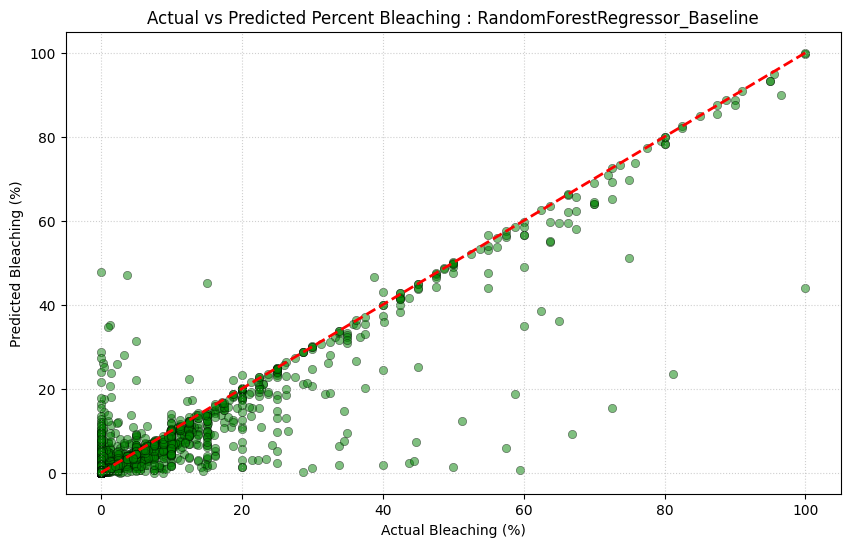

In [34]:
all_results_baseline = []

for model, model_name, color in algo_baseline:

    print(f"\n========== {model_name} ==========")

    models, oof_preds, rmse_scores, mae_scores, r2_scores = Baseline_model(
        feature_Baseline.values,
        target_Regression_36.values,
        model,
        n_splits=5
    )

    all_results_baseline.append({
        'model': model_name,
        'RMSE_mean': np.mean(rmse_scores),
        'MAE_mean': np.mean(mae_scores),
        'R2_mean': np.mean(r2_scores)
    })
    
    PLOTING_RESULT_ML(
        model,
        X_test=feature_Baseline.values,
        y_test=target_Regression_36.values,
        cl=color,
        name=model_name
    )

##

### model 2th : Baseline + features is 36 features ---> RF (Hyperparameter tunning)


========== RandomForestRegressor_Baseline_togetherOtherfeatures ==========

===== Fold 1 / 5 =====
Fold RMSE : 8.3531
Fold MAE  : 3.1546
Fold R2   : 0.1899

===== Fold 2 / 5 =====
Fold RMSE : 7.6387
Fold MAE  : 2.9509
Fold R2   : 0.4248

===== Fold 3 / 5 =====
Fold RMSE : 6.9491
Fold MAE  : 2.6915
Fold R2   : 0.5108

===== Fold 4 / 5 =====
Fold RMSE : 7.7971
Fold MAE  : 2.8025
Fold R2   : 0.3002

===== Fold 5 / 5 =====
Fold RMSE : 6.6092
Fold MAE  : 2.6331
Fold R2   : 0.5191


Mean RMSE : 7.4694
Mean MAE  : 2.8465
Mean R2   : 0.3890


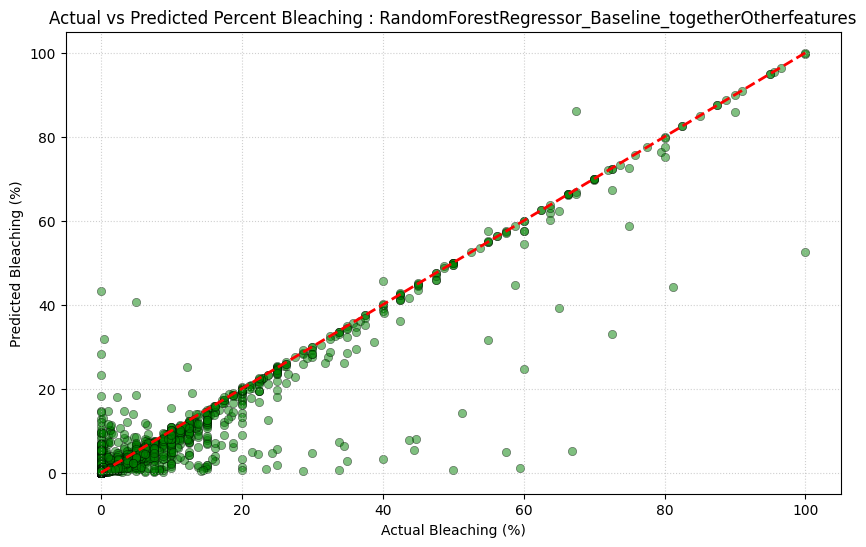


Feature Importance:
                                  feature  importance
2                                 Depth_m    0.075780
31                                TSA_DHW    0.072639
0                        Latitude_Degrees    0.055287
1                       Longitude_Degrees    0.051207
18                               SSTA_DHW    0.050259
14                         SSTA_Frequency    0.047498
35                                   Year    0.046392
4                      Temperature_Kelvin    0.042516
10                                   SSTA    0.034838
22                                    TSA    0.033362
27                          TSA_Frequency    0.031279
9                               Windspeed    0.028001
28       TSA_Frequency_Standard_Deviation    0.026740
25                            TSA_Maximum    0.023656
3                                 ClimSST    0.022410
13                           SSTA_Maximum    0.021549
33                             TSA_DHWMax    0.021140
12     

In [37]:
algo_baselinefeature = [
    [RandomForestRegressor(max_features = 'sqrt', max_depth = 16, criterion = 'squared_error', bootstrap = False,
                           n_estimators = 300, 
                           random_state = 42), 'RandomForestRegressor_Baseline_togetherOtherfeatures', 'green']
]

all_results_baseline = []

for model, model_name, color in algo_baselinefeature:

    print(f"\n========== {model_name} ==========")

    models, oof_preds, rmse_scores, mae_scores, r2_scores = Baseline_model(
        feature_original_36.values,
        target_Regression_36.values,
        model,
        n_splits=5
    )

    all_results_baseline.append({
        'model': model_name,
        'RMSE_mean': np.mean(rmse_scores),
        'MAE_mean': np.mean(mae_scores),
        'R2_mean': np.mean(r2_scores)
    })
    
    PLOTING_RESULT_ML(
        models[0],
        X_test=feature_original_36.values,
        y_test=target_Regression_36.values,
        cl=color,
        name=model_name
    )
    
feature_importance_df = feature_importance(models[0], feature_original_36)
print("\nFeature Importance:")
print(feature_importance_df)

##

##

### model 3th : Naive Baseline

In [ ]:
#------------------------------------------------------------------------#
# Average Bleaching Model — Naïve Baseline
#------------------------------------------------------------------------#

y_true = target_Regression_36.values
y_pred_avg = y_true.mean()  # baseline prediction: predict the mean for every sample

def RMSE(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def R2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    print(f"  SS_res : {ss_res:.1f}")
    print(f"  SS_tot : {ss_tot:.1f}")
    return 1 - (ss_res / ss_tot)

print(f"Baseline prediction (mean): {y_pred_avg:.4f}")
print("-" * 50)
print(f"RMSE    : {RMSE(y_true, y_pred_avg):.4f}")
print(f"R²      : {R2_score(y_true, y_pred_avg):.4f}")

Baseline prediction (mean): 2.7952
--------------------------------------------------
RMSE    : 9.6333
  SS_res : 567199.4
  SS_tot : 567199.4
R²      : 0.0000


##

def plot_confusion_matrix(y_true, y_pred, classes, name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    plt.title(f"Confusion Matrix of = {name}")
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

In [ ]:
def plot_confusion_matrix(y_true, y_pred, labels=['False', 'True'], title="OOF Confusion Matrix"):
    
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=labels))
    
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")

    ax.set_title(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

=========================
### Proposed Method
=========================

In [ ]:
algo_Class = [
    [RandomForestClassifier(max_features = 'sqrt', max_depth = 16, criterion = 'entropy', bootstrap = False,
                           n_estimators = 300, 
                           random_state = 42), 'RandomForestClassifier'],
    
    [lgb.LGBMClassifier(class_weight='balanced',
                        n_estimators=1000,
                        learning_rate=0.05,
                        max_depth=6,
                        random_state=42,
                        verbose=-1), 'LGBMClassifier'],
    
    [XGBClassifier(n_estimators=500,
                  max_depth=5,            # ไม่ต้องลึกมาก XGBoost ฉลาดพอ
                  learning_rate=0.05,     # ค่อยๆ เรียนรู้ทีละนิด (ยิ่งน้อยยิ่งแม่น แต่เทรนนาน)
                  subsample=0.8,          # สุ่มข้อมูลมาเทรน 80% ต่อรอบ (ช่วยกันจำข้อสอบ)
                  colsample_bytree=0.8,   # สุ่มตัวแปรมา 80% ต่อรอบ
                  random_state=42,
                  n_jobs=-1,
                  verbosity=0), 'XGBClassifier'],
]

In [ ]:
algo_reg = [

    [RandomForestRegressor(max_depth=10, 
                           max_features='log2', 
                           min_samples_leaf=4, 
                           min_samples_split=2, 
                           n_estimators=200,
                           random_state=42), 'RandomForestRegressor' , 'blue'],
    
    [lgb.LGBMRegressor(colsample_bytree=0.6, 
                       learning_rate=0.01, 
                       max_depth=-1, 
                       n_estimators=1000, 
                       num_leaves=50, 
                       subsample=1.0,
                       random_state=42), 'LGBMRegressor' , 'green'],
    
    [XGBRegressor(colsample_bytree=0.6, 
                  learning_rate=0.01, 
                  max_depth=5, 
                  min_child_weight=3, 
                  n_estimators=500, 
                  subsample=0.8, 
                  gamma=0.2,
                  random_state=42), 'XGBRegressor' , 'orange']

]

In [ ]:
import warnings
from sklearn.exceptions import DataConversionWarning
# -----------------------------
# ปิด warning
# -----------------------------
warnings.filterwarnings("ignore", category=DataConversionWarning)
warnings.filterwarnings("ignore", category=UserWarning)


algo_method = [
    [RandomForestClassifier(max_features = 'sqrt', max_depth = 16, criterion = 'entropy', bootstrap = False,
                           n_estimators = 300, 
                           random_state = 42),
     'RandomForestClassifier_Method',
     
     RandomForestRegressor(max_depth=20, 
                           max_features='sqrt', 
                           min_samples_leaf=1, 
                           min_samples_split=2, 
                           n_estimators=500,
                           random_state=42),
     'RandomForestRegressor_Method',
     'blue'
    ],
    
    
    [lgb.LGBMClassifier(class_weight='balanced',
                        n_estimators=1000,
                        learning_rate=0.01,
                        max_depth=-1,
                        random_state=42,
                        verbose=-1), 
     'LGBMClassifier_Method',
     
     lgb.LGBMRegressor(colsample_bytree=0.6, 
                       learning_rate=0.01, 
                       max_depth=-1, 
                       n_estimators=1000, 
                       num_leaves=50, 
                       subsample=1.0,
                       random_state=42), 
     'LGBMRegressor_Method',
     'green'
    ],
    
    
    [XGBClassifier(n_estimators=500,
                  max_depth=5,            # ไม่ต้องลึกมาก XGBoost ฉลาดพอ
                  learning_rate=0.05,     # ค่อยๆ เรียนรู้ทีละนิด (ยิ่งน้อยยิ่งแม่น แต่เทรนนาน)
                  subsample=0.8,          # สุ่มข้อมูลมาเทรน 80% ต่อรอบ (ช่วยกันจำข้อสอบ)
                  colsample_bytree=0.8,   # สุ่มตัวแปรมา 80% ต่อรอบ
                  random_state=42,
                  n_jobs=-1,
                  verbosity=0), 
     'XGBClassifier_Method',
      
      XGBRegressor(colsample_bytree=0.6, 
                  learning_rate=0.01, 
                  max_depth=5, 
                  min_child_weight=3, 
                  n_estimators=500, 
                  subsample=0.8, 
                  gamma=0.2,
                  random_state=42), 
      'XGBRegressor_Method', 
      'orange'  
    ]
        
]

In [ ]:
algo_method[0][4]

'blue'

In [ ]:
def Proposed_method_Classify(X_train, y_train, model, n_splits=5, threshold=0.5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    oof_proba = np.zeros(len(X_train))   # เก็บ probability
    oof_label = np.zeros(len(X_train))   # เก็บ predicted class (สำหรับ Confusion Matrix)
    
    models = []
    auc_scores = []

    y_train = np.array(y_train).ravel()

    def _index(arr, idx):
        if hasattr(arr, 'iloc'):
            return arr.iloc[idx].values
        return arr[idx]

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
        print(f"\n===== Fold {fold + 1} / {n_splits} =====")

        X_tr  = _index(X_train, train_idx)
        X_val = _index(X_train, val_idx)
        y_tr  = y_train[train_idx]
        y_val = y_train[val_idx]

        clf = clone(model)               # ✅ clone ใหม่ทุก fold
        clf.fit(X_tr, y_tr)

        proba = clf.predict_proba(X_val)[:, 1]
        label = (proba >= threshold).astype(int)   # ✅ แปลงเป็น class label

        oof_proba[val_idx] = proba
        oof_label[val_idx] = label

        fold_auc = roc_auc_score(y_val, proba)
        auc_scores.append(fold_auc)
        models.append(clf)

        print(f"Fold {fold + 1} AUC: {fold_auc:.4f}")

    # ── Overall OOF metrics ──────────────────────────────────────────
    oof_auc = roc_auc_score(y_train, oof_proba)
    print(f"\nOOF AUC  : {oof_auc:.4f}")
    print(f"Mean CV AUC: {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")

    # ── Confusion Matrix (OOF ทั้งหมด) ──────────────────────────────
    plot_confusion_matrix(y_train, oof_label)

    return models, oof_proba, oof_label, auc_scores


In [ ]:
def Proposed_method_Regression(X_train, y_train, model, n_splits=5):

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    oof_preds   = np.zeros(len(X_train))
    models      = []
    rmse_scores = []
    mae_scores  = []
    r2_scores   = []

    y_train = np.array(y_train).ravel()

    # ✅ รองรับทั้ง DataFrame และ numpy array
    def _index(arr, idx):
        if hasattr(arr, 'iloc'):
            return arr.iloc[idx].values
        return arr[idx]

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):  # ✅ KFold ไม่ต้องส่ง y

        print(f"\n===== Fold {fold+1} / {n_splits} =====")

        X_tr  = _index(X_train, train_idx)
        X_val = _index(X_train, val_idx)
        y_tr  = y_train[train_idx]
        y_val = y_train[val_idx]

        reg = clone(model)   # ✅ clone ใหม่ทุก fold
        reg.fit(X_tr, y_tr)

        pred = reg.predict(X_val)
        oof_preds[val_idx] = pred

        rmse = np.sqrt(mean_squared_error(y_val, pred))
        mae  = mean_absolute_error(y_val, pred)
        r2   = r2_score(y_val, pred)

        rmse_scores.append(rmse)
        mae_scores.append(mae)
        r2_scores.append(r2)
        models.append(reg)

        print(f"Fold RMSE : {rmse:.4f}")
        print(f"Fold MAE  : {mae:.4f}")
        print(f"Fold R2   : {r2:.4f}")

    print(f"\nMean RMSE : {np.mean(rmse_scores):.4f}")
    print(f"Mean MAE  : {np.mean(mae_scores):.4f}")
    print(f"Mean R2   : {np.mean(r2_scores):.4f}")
    print("=" * 50)

    return models, oof_preds, rmse_scores, mae_scores, r2_scores

In [ ]:
def Proposed_method_together(X_train, y_train_Classify, y_train_Regression,
                              algo_method, n_splits=5):

    all_results = []

    for clf, clf_name, reg, reg_name, color in algo_method:

        print(f"\n{'='*98}")
        print(f"  {clf_name}  +  {reg_name}")
        print(f"{'='*98}")

        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

        oof_proba    = np.zeros(len(X_train))
        oof_label    = np.zeros(len(X_train))
        oof_reg_pred = np.full(len(X_train), np.nan)   # nan = ไม่ได้ predict (class 0)

        auc_scores  = []
        rmse_scores = []
        mae_scores  = []
        r2_scores   = []

        clf_models = []
        reg_models = []

        X_arr = X_train.values if hasattr(X_train, 'iloc') else X_train
        y_cls = np.array(y_train_Classify).ravel()
        y_reg = np.array(y_train_Regression).ravel()

        for fold, (train_idx, val_idx) in enumerate(skf.split(X_arr, y_cls)):

            print(f"\n----- Fold {fold+1} / {n_splits} -----")

            X_tr  = X_arr[train_idx];  X_val  = X_arr[val_idx]
            y_cls_tr = y_cls[train_idx]; y_cls_val = y_cls[val_idx]
            y_reg_tr = y_reg[train_idx]; y_reg_val = y_reg[val_idx]

            # ── Stage 1 : Train Classifier ───────────────────────────
            clf_fold = clone(clf)
            clf_fold.fit(X_tr, y_cls_tr)

            proba = clf_fold.predict_proba(X_val)[:, 1]
            label = (proba >= 0.5).astype(int)

            oof_proba[val_idx] = proba
            oof_label[val_idx] = label

            auc = roc_auc_score(y_cls_val, proba)
            auc_scores.append(auc)
            clf_models.append(clf_fold)
            print(f"[CLF] AUC : {auc:.4f}")

            # ── Stage 2 : Train Regressor เฉพาะ class 1 ใน fold นี้ ──
            # กรองจาก y_cls_tr จริง (ไม่ใช่ prediction)
            pos_tr  = y_cls_tr == 1        # ✅ ใช้ label จริงตอน train
            pos_val = label == 1           # ✅ ใช้ prediction ตอน val (ไม่รู้ label จริง)

            if pos_tr.sum() == 0:
                print(f"[REG] ⚠️  ไม่มี class 1 ใน train fold นี้ ข้าม")
                reg_models.append(None)
                continue

            X_reg_tr  = X_tr[pos_tr];   y_reg_tr_pos = y_reg_tr[pos_tr]
            X_reg_val = X_val[pos_val]

            reg_fold = clone(reg)
            reg_fold.fit(X_reg_tr, y_reg_tr_pos)
            reg_models.append(reg_fold)

            if pos_val.sum() > 0:
                # predict ครั้งเดียวจาก X_reg_val = X_val[pos_val]
                pred_reg = reg_fold.predict(X_reg_val)
                oof_reg_pred[val_idx[pos_val]] = pred_reg

            # ── Metric วัดเฉพาะ val ที่ predict=1 และ label จริง=1 ──────
            # both_pos_local: index ภายใน pred_reg/pos_val array
            true_pos_val   = y_cls_val == 1                  # mask บน val_idx ทั้งหมด
            both_pos_local = true_pos_val[pos_val]            # ✅ กรองให้ตรงกับ pred_reg

            if both_pos_local.sum() > 0:
                y_true_eval = y_reg_val[pos_val][both_pos_local]   # ✅ จาก val จริง
                y_pred_eval = pred_reg[both_pos_local]              # ✅ จาก prediction val

                rmse = np.sqrt(mean_squared_error(y_true_eval, y_pred_eval))
                mae  = mean_absolute_error(y_true_eval, y_pred_eval)
                r2   = r2_score(y_true_eval, y_pred_eval)

                rmse_scores.append(rmse)
                mae_scores.append(mae)
                r2_scores.append(r2)
                print(f"[REG] RMSE: {rmse:.4f} | MAE: {mae:.4f} | R2: {r2:.4f}")
            else:
                print(f"[REG] ไม่มี sample ที่ predict เป็น class 1 ใน val fold นี้")

        # ── Overall Summary ──────────────────────────────────────────
        print(f"\n{'='*55}")
        print(f"OOF AUC      : {roc_auc_score(y_cls, oof_proba):.4f}")
        print(f"Mean CV AUC  : {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")
        if rmse_scores:
            print(f"Mean RMSE    : {np.mean(rmse_scores):.4f}")
            print(f"Mean MAE     : {np.mean(mae_scores):.4f}")
            print(f"Mean R2      : {np.mean(r2_scores):.4f}")

        plot_confusion_matrix(y_cls, oof_label.astype(int))

        all_results.append({
            'clf_name'    : clf_name,   'reg_name'    : reg_name,
            'color'       : color,
            'clf_models'  : clf_models, 'reg_models'  : reg_models,
            'oof_proba'   : oof_proba,  'oof_label'   : oof_label,
            'oof_reg_pred': oof_reg_pred,
            'auc_scores'  : auc_scores,
            'rmse_scores' : rmse_scores,'mae_scores'  : mae_scores,
            'r2_scores'   : r2_scores,
        })

    return all_results


  RandomForestClassifier_Method  +  RandomForestRegressor_Method

----- Fold 1 / 5 -----
[CLF] AUC : 0.8378
[REG] RMSE: 13.6298 | MAE: 8.9795 | R2: 0.5005

----- Fold 2 / 5 -----
[CLF] AUC : 0.8274
[REG] RMSE: 15.5060 | MAE: 9.4373 | R2: 0.5092

----- Fold 3 / 5 -----
[CLF] AUC : 0.8454
[REG] RMSE: 14.3421 | MAE: 8.1271 | R2: 0.4416

----- Fold 4 / 5 -----
[CLF] AUC : 0.8343
[REG] RMSE: 13.9847 | MAE: 8.1502 | R2: 0.5227

----- Fold 5 / 5 -----
[CLF] AUC : 0.8444
[REG] RMSE: 10.2589 | MAE: 6.3225 | R2: 0.5678

OOF AUC      : 0.8376
Mean CV AUC  : 0.8379 ± 0.0067
Mean RMSE    : 13.5443
Mean MAE     : 8.2033
Mean R2      : 0.5084

Classification Report:
              precision    recall  f1-score   support

       False       0.84      0.91      0.88      4513
        True       0.67      0.53      0.59      1599

    accuracy                           0.81      6112
   macro avg       0.76      0.72      0.73      6112
weighted avg       0.80      0.81      0.80      6112



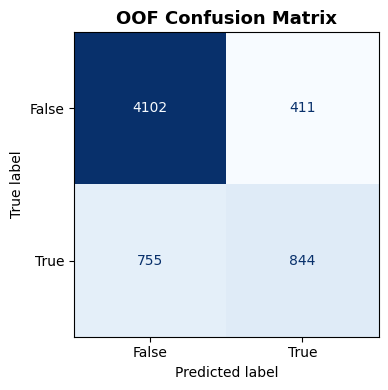


  LGBMClassifier_Method  +  LGBMRegressor_Method

----- Fold 1 / 5 -----
[CLF] AUC : 0.8352
[REG] RMSE: 13.7613 | MAE: 8.6319 | R2: 0.4529

----- Fold 2 / 5 -----
[CLF] AUC : 0.8383
[REG] RMSE: 14.2898 | MAE: 8.3242 | R2: 0.5166

----- Fold 3 / 5 -----
[CLF] AUC : 0.8527
[REG] RMSE: 14.7898 | MAE: 8.2670 | R2: 0.4077

----- Fold 4 / 5 -----
[CLF] AUC : 0.8454
[REG] RMSE: 13.7274 | MAE: 8.2337 | R2: 0.4491

----- Fold 5 / 5 -----
[CLF] AUC : 0.8413
[REG] RMSE: 10.4487 | MAE: 6.5133 | R2: 0.5062

OOF AUC      : 0.8421
Mean CV AUC  : 0.8426 ± 0.0061
Mean RMSE    : 13.4034
Mean MAE     : 7.9940
Mean R2      : 0.4665

Classification Report:
              precision    recall  f1-score   support

       False       0.88      0.82      0.85      4513
        True       0.58      0.68      0.63      1599

    accuracy                           0.79      6112
   macro avg       0.73      0.75      0.74      6112
weighted avg       0.80      0.79      0.79      6112



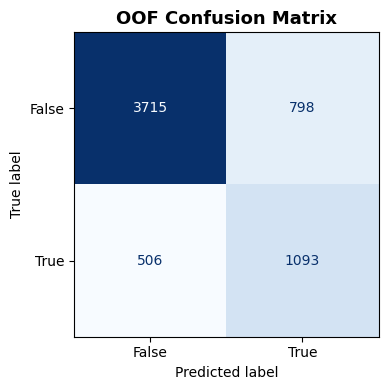


  XGBClassifier_Method  +  XGBRegressor_Method

----- Fold 1 / 5 -----
[CLF] AUC : 0.8356
[REG] RMSE: 14.2625 | MAE: 9.5069 | R2: 0.4768

----- Fold 2 / 5 -----
[CLF] AUC : 0.8354
[REG] RMSE: 16.4352 | MAE: 9.8124 | R2: 0.4686

----- Fold 3 / 5 -----
[CLF] AUC : 0.8492
[REG] RMSE: 14.1166 | MAE: 8.1337 | R2: 0.4627

----- Fold 4 / 5 -----
[CLF] AUC : 0.8446
[REG] RMSE: 15.1163 | MAE: 9.1265 | R2: 0.4525

----- Fold 5 / 5 -----
[CLF] AUC : 0.8360
[REG] RMSE: 10.1756 | MAE: 6.4711 | R2: 0.5832

OOF AUC      : 0.8400
Mean CV AUC  : 0.8401 ± 0.0057
Mean RMSE    : 14.0212
Mean MAE     : 8.6101
Mean R2      : 0.4887

Classification Report:
              precision    recall  f1-score   support

       False       0.84      0.91      0.88      4513
        True       0.68      0.52      0.59      1599

    accuracy                           0.81      6112
   macro avg       0.76      0.72      0.73      6112
weighted avg       0.80      0.81      0.80      6112



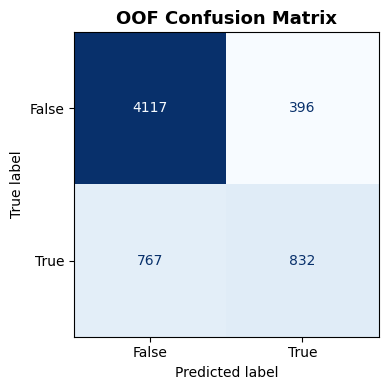

In [ ]:
# ── เรียกใช้ ─────────────────────────────────────────────────────────
all_results_method = Proposed_method_together(
    feature_original_36,
    target_Classify_36,
    target_Regression_36,
    algo_method,          # ✅ ส่ง algo_method เข้าไปตรงๆ
    n_splits=5
)

##

### model 5th : Prposed Method + Input follow thinking


  RandomForestClassifier_Method  +  RandomForestRegressor_Method

----- Fold 1 / 5 -----
[CLF] AUC : 0.8323
[REG] RMSE: 14.3537 | MAE: 9.5830 | R2: 0.4784

----- Fold 2 / 5 -----
[CLF] AUC : 0.8309
[REG] RMSE: 16.5694 | MAE: 10.1144 | R2: 0.4664

----- Fold 3 / 5 -----
[CLF] AUC : 0.8495
[REG] RMSE: 15.5493 | MAE: 8.8609 | R2: 0.3787

----- Fold 4 / 5 -----
[CLF] AUC : 0.8458
[REG] RMSE: 14.2523 | MAE: 8.6977 | R2: 0.5230

----- Fold 5 / 5 -----
[CLF] AUC : 0.8462
[REG] RMSE: 10.8718 | MAE: 6.7273 | R2: 0.5288

OOF AUC      : 0.8407
Mean CV AUC  : 0.8409 ± 0.0077
Mean RMSE    : 14.3193
Mean MAE     : 8.7967
Mean R2      : 0.4751

Classification Report:
              precision    recall  f1-score   support

       False       0.84      0.92      0.88      4513
        True       0.70      0.51      0.59      1599

    accuracy                           0.81      6112
   macro avg       0.77      0.72      0.73      6112
weighted avg       0.80      0.81      0.80      6112



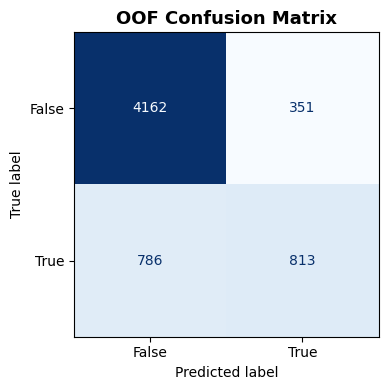


  LGBMClassifier_Method  +  LGBMRegressor_Method

----- Fold 1 / 5 -----
[CLF] AUC : 0.8306
[REG] RMSE: 13.4757 | MAE: 8.8581 | R2: 0.4479

----- Fold 2 / 5 -----
[CLF] AUC : 0.8243
[REG] RMSE: 13.8459 | MAE: 8.3448 | R2: 0.5109

----- Fold 3 / 5 -----
[CLF] AUC : 0.8479
[REG] RMSE: 15.9312 | MAE: 9.1312 | R2: 0.3416

----- Fold 4 / 5 -----
[CLF] AUC : 0.8420
[REG] RMSE: 13.1428 | MAE: 7.8958 | R2: 0.5007

----- Fold 5 / 5 -----
[CLF] AUC : 0.8390
[REG] RMSE: 10.9084 | MAE: 6.6670 | R2: 0.4265

OOF AUC      : 0.8365
Mean CV AUC  : 0.8368 ± 0.0084
Mean RMSE    : 13.4608
Mean MAE     : 8.1794
Mean R2      : 0.4455

Classification Report:
              precision    recall  f1-score   support

       False       0.88      0.83      0.85      4513
        True       0.58      0.68      0.63      1599

    accuracy                           0.79      6112
   macro avg       0.73      0.75      0.74      6112
weighted avg       0.80      0.79      0.79      6112



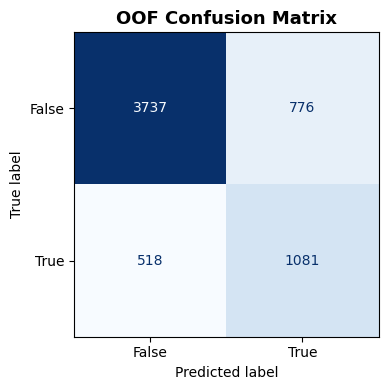


  XGBClassifier_Method  +  XGBRegressor_Method

----- Fold 1 / 5 -----
[CLF] AUC : 0.8370
[REG] RMSE: 14.8844 | MAE: 9.9215 | R2: 0.4589

----- Fold 2 / 5 -----
[CLF] AUC : 0.8298
[REG] RMSE: 16.6031 | MAE: 10.2570 | R2: 0.4603

----- Fold 3 / 5 -----
[CLF] AUC : 0.8487
[REG] RMSE: 15.5445 | MAE: 8.8098 | R2: 0.3669

----- Fold 4 / 5 -----
[CLF] AUC : 0.8455
[REG] RMSE: 14.5655 | MAE: 8.9365 | R2: 0.5056

----- Fold 5 / 5 -----
[CLF] AUC : 0.8496
[REG] RMSE: 10.7275 | MAE: 6.7576 | R2: 0.5260

OOF AUC      : 0.8419
Mean CV AUC  : 0.8421 ± 0.0076
Mean RMSE    : 14.4650
Mean MAE     : 8.9365
Mean R2      : 0.4635

Classification Report:
              precision    recall  f1-score   support

       False       0.84      0.92      0.88      4513
        True       0.69      0.50      0.58      1599

    accuracy                           0.81      6112
   macro avg       0.76      0.71      0.73      6112
weighted avg       0.80      0.81      0.80      6112



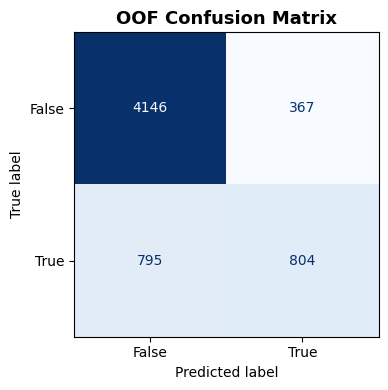

In [ ]:
# ── เรียกใช้ ─────────────────────────────────────────────────────────
all_results_method = Proposed_method_together(
    feature_method,
    target_methodClassify,
    target_methodRegression,
    algo_method,          # ✅ ส่ง algo_method เข้าไปตรงๆ
    n_splits=5
)

##

##

### model 6th : Proposed - Severity Gate  36 features ---> XGB

In [ ]:
all_results = []

for model, model_name, color in algo_reg:

    print(f"\n========== {model_name} ==========")

    models, oof_preds, rmse_scores, mae_scores, r2_scores = Proposed_method_Regression(
        feature_original_36.values,
        target_Regression_36.values,
        model,
        n_splits=5
    )

    all_results.append({
        'model': model_name,
        'RMSE_mean': np.mean(rmse_scores),
        'MAE_mean': np.mean(mae_scores),
        'R2_mean': np.mean(r2_scores)
    })


========== RandomForestRegressor ==========

===== Fold 1 / 5 =====
Fold RMSE : 7.5108
Fold MAE  : 3.2759
Fold R2   : 0.3450

===== Fold 2 / 5 =====
Fold RMSE : 7.8820
Fold MAE  : 3.3628
Fold R2   : 0.3876

===== Fold 3 / 5 =====
Fold RMSE : 7.4034
Fold MAE  : 3.2028
Fold R2   : 0.4447

===== Fold 4 / 5 =====
Fold RMSE : 7.5198
Fold MAE  : 3.1795
Fold R2   : 0.3491

===== Fold 5 / 5 =====
Fold RMSE : 6.9378
Fold MAE  : 3.1178
Fold R2   : 0.4700

Mean RMSE : 7.4507
Mean MAE  : 3.2278
Mean R2   : 0.3993

========== LGBMRegressor ==========

===== Fold 1 / 5 =====
Fold RMSE : 7.6300
Fold MAE  : 3.1548
Fold R2   : 0.3241

===== Fold 2 / 5 =====
Fold RMSE : 7.4710
Fold MAE  : 3.1041
Fold R2   : 0.4498

===== Fold 3 / 5 =====
Fold RMSE : 6.7543
Fold MAE  : 2.8670
Fold R2   : 0.5378

===== Fold 4 / 5 =====
Fold RMSE : 7.2622
Fold MAE  : 2.8600
Fold R2   : 0.3930

===== Fold 5 / 5 =====
Fold RMSE : 6.6194
Fold MAE  : 2.8351
Fold R2   : 0.5176

Mean RMSE : 7.1474
Mean MAE  : 2.9642
Mean R2   :

##

##

### model 7th : Proposed - PCA  ---> prop

In [ ]:
def Data_preparation_for_model7th(df,df_Baseline, df_additive):
    
    feature = pd.concat(
        [df_Baseline.reset_index(drop=True), df_additive.reset_index(drop=True)],
        axis=1
        
    )
    
    target_Classify = (df['Percent_Bleaching'] >= 1).astype(int)
    target_Regression = df[['Percent_Bleaching']]
    
    return feature, target_Classify, target_Regression

feature_7th, target_Classify_7th, target_Regression_for_model7th = Data_preparation_for_model7th(df_principal, df_paper_groupby, df_Additive_groupby)
feature_7th.shape, target_Classify_7th.shape, target_Regression_for_model7th.shape

((6112, 7), (6112,), (6112, 1))

In [ ]:
algo_method_7th = [
    [RandomForestClassifier(max_features = 'sqrt', 
                            max_depth = 16, 
                            criterion = 'entropy', 
                            bootstrap = False,
                           n_estimators = 300, 
                           random_state = 42),
     'RandomForestClassifier_Method',
     
     RandomForestRegressor(max_depth=10, 
                           max_features='sqrt', 
                           min_samples_leaf=4, 
                           min_samples_split=10, 
                           n_estimators=300,
                           random_state=42),
     'RandomForestRegressor_Method',
     'blue'
    ],
    
    
    [lgb.LGBMClassifier(class_weight='balanced',
                        n_estimators=1000,
                        learning_rate=0.01,
                        max_depth=-1,
                        random_state=42,
                        verbose=-1), 
     'LGBMClassifier_Method',
     
     lgb.LGBMRegressor(colsample_bytree=1.0, 
                       learning_rate=0.01, 
                       max_depth=10, 
                       n_estimators=500, 
                       num_leaves=15, 
                       subsample=1.0,
                       random_state=42), 
     'LGBMRegressor_Method',
     'green'
    ],
    
    
    [XGBClassifier(n_estimators=300,
                  max_depth=4,            # ไม่ต้องลึกมาก XGBoost ฉลาดพอ
                  learning_rate=0.05,     # ค่อยๆ เรียนรู้ทีละนิด (ยิ่งน้อยยิ่งแม่น แต่เทรนนาน)
                  subsample=0.8,          # สุ่มข้อมูลมาเทรน 80% ต่อรอบ (ช่วยกันจำข้อสอบ)
                  colsample_bytree=0.8,   # สุ่มตัวแปรมา 80% ต่อรอบ
                  random_state=42,
                  n_jobs=-1,
                  verbosity=0), 
     'XGBClassifier_Method',
      
      XGBRegressor(colsample_bytree=0.6, 
                  learning_rate=0.01, 
                  max_depth=4, 
                  min_child_weight=3, 
                  n_estimators=300, 
                  subsample=0.8, 
                  gamma=0.1,
                  random_state=42), 
      'XGBRegressor_Method', 
      'orange'  
    ]
]


  RandomForestClassifier_Method  +  RandomForestRegressor_Method

----- Fold 1 / 5 -----
[CLF] AUC : 0.8211
[REG] RMSE: 15.7696 | MAE: 10.1594 | R2: 0.3599

----- Fold 2 / 5 -----
[CLF] AUC : 0.8239
[REG] RMSE: 19.1076 | MAE: 11.3487 | R2: 0.3029

----- Fold 3 / 5 -----
[CLF] AUC : 0.8419
[REG] RMSE: 16.9308 | MAE: 10.0166 | R2: 0.3107

----- Fold 4 / 5 -----
[CLF] AUC : 0.8299
[REG] RMSE: 16.4906 | MAE: 9.9317 | R2: 0.3793

----- Fold 5 / 5 -----
[CLF] AUC : 0.8251
[REG] RMSE: 11.3059 | MAE: 7.5243 | R2: 0.5333

OOF AUC      : 0.8281
Mean CV AUC  : 0.8284 ± 0.0073
Mean RMSE    : 15.9209
Mean MAE     : 9.7961
Mean R2      : 0.3772

Classification Report:
              precision    recall  f1-score   support

       False       0.83      0.93      0.87      4513
        True       0.69      0.45      0.55      1599

    accuracy                           0.80      6112
   macro avg       0.76      0.69      0.71      6112
weighted avg       0.79      0.80      0.79      6112



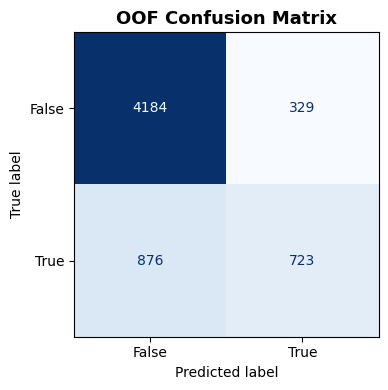


  LGBMClassifier_Method  +  LGBMRegressor_Method

----- Fold 1 / 5 -----
[CLF] AUC : 0.8063
[REG] RMSE: 15.6062 | MAE: 9.9894 | R2: 0.3271

----- Fold 2 / 5 -----
[CLF] AUC : 0.8175
[REG] RMSE: 16.6002 | MAE: 10.0334 | R2: 0.3158

----- Fold 3 / 5 -----
[CLF] AUC : 0.8171
[REG] RMSE: 15.7773 | MAE: 9.3337 | R2: 0.3110

----- Fold 4 / 5 -----
[CLF] AUC : 0.8103
[REG] RMSE: 15.4194 | MAE: 9.8847 | R2: 0.3110

----- Fold 5 / 5 -----
[CLF] AUC : 0.8087
[REG] RMSE: 11.3162 | MAE: 7.3679 | R2: 0.4198

OOF AUC      : 0.8116
Mean CV AUC  : 0.8120 ± 0.0045
Mean RMSE    : 14.9438
Mean MAE     : 9.3218
Mean R2      : 0.3369

Classification Report:
              precision    recall  f1-score   support

       False       0.88      0.78      0.83      4513
        True       0.53      0.69      0.60      1599

    accuracy                           0.76      6112
   macro avg       0.70      0.73      0.71      6112
weighted avg       0.78      0.76      0.77      6112



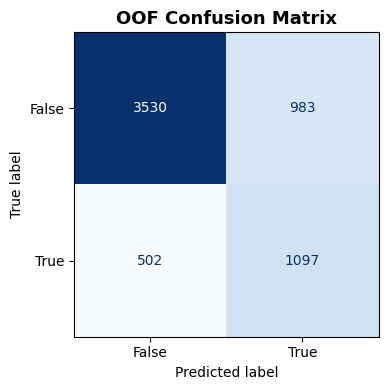


  XGBClassifier_Method  +  XGBRegressor_Method

----- Fold 1 / 5 -----
[CLF] AUC : 0.7876
[REG] RMSE: 18.9914 | MAE: 11.5927 | R2: 0.2290

----- Fold 2 / 5 -----
[CLF] AUC : 0.8046
[REG] RMSE: 19.4511 | MAE: 12.1526 | R2: 0.2502

----- Fold 3 / 5 -----
[CLF] AUC : 0.8081
[REG] RMSE: 17.9700 | MAE: 10.8118 | R2: 0.2828

----- Fold 4 / 5 -----
[CLF] AUC : 0.8008
[REG] RMSE: 16.2755 | MAE: 10.6572 | R2: 0.2624

----- Fold 5 / 5 -----
[CLF] AUC : 0.7951
[REG] RMSE: 12.6534 | MAE: 8.0505 | R2: 0.4895

OOF AUC      : 0.7989
Mean CV AUC  : 0.7992 ± 0.0072
Mean RMSE    : 17.0683
Mean MAE     : 10.6530
Mean R2      : 0.3028

Classification Report:
              precision    recall  f1-score   support

       False       0.80      0.94      0.87      4513
        True       0.68      0.34      0.45      1599

    accuracy                           0.79      6112
   macro avg       0.74      0.64      0.66      6112
weighted avg       0.77      0.79      0.76      6112



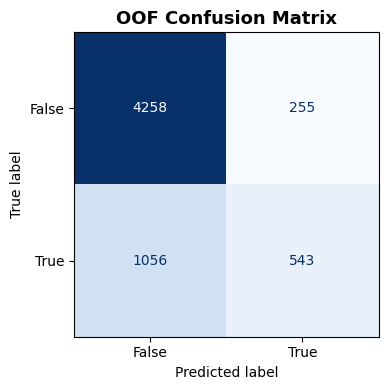

In [ ]:
# ── เรียกใช้ ─────────────────────────────────────────────────────────
all_results_method = Proposed_method_together(
    feature_7th,
    target_Classify_7th,
    target_Regression_for_model7th,
    algo_method_7th,          # ✅ ส่ง algo_method_7th เข้าไปตรงๆ
    n_splits=5
)

##

### model 8th : Baseline + additive feature ---> RF


========== RandomForestRegressor_Baseline_Additivefeatures ==========

===== Fold 1 / 5 =====
Fold RMSE : 8.2343
Fold MAE  : 3.5122
Fold R2   : 0.2128

===== Fold 2 / 5 =====
Fold RMSE : 8.5206
Fold MAE  : 3.6628
Fold R2   : 0.2844

===== Fold 3 / 5 =====
Fold RMSE : 8.2989
Fold MAE  : 3.5018
Fold R2   : 0.3023

===== Fold 4 / 5 =====
Fold RMSE : 8.2331
Fold MAE  : 3.5257
Fold R2   : 0.2198

===== Fold 5 / 5 =====
Fold RMSE : 7.5659
Fold MAE  : 3.4568
Fold R2   : 0.3697


Mean RMSE : 8.1706
Mean MAE  : 3.5319
Mean R2   : 0.2778


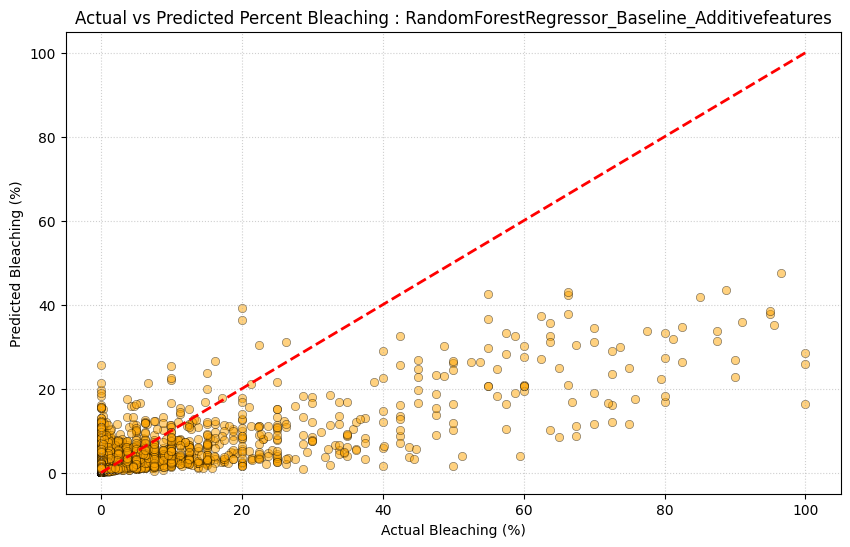

In [ ]:
algo_Additivefeature = [
    [RandomForestRegressor(max_depth=10, 
                           max_features='sqrt', 
                           min_samples_leaf=4, 
                           min_samples_split=10, 
                           n_estimators=300,
                           random_state=42), 'RandomForestRegressor_Baseline_Additivefeatures', 'orange']
]

all_results_Additive = []

for model, model_name, color in algo_Additivefeature:

    print(f"\n========== {model_name} ==========")

    models, oof_preds, rmse_scores, mae_scores, r2_scores = Baseline_model(
        feature_7th.values,
        target_Regression_for_model7th.values,
        model,
        n_splits=5
    )

    all_results_Additive.append({
        'model': model_name,
        'RMSE_mean': np.mean(rmse_scores),
        'MAE_mean': np.mean(mae_scores),
        'R2_mean': np.mean(r2_scores)
    })
    
    PLOTING_RESULT_ML(
        model,
        X_test=feature_7th.values,
        y_test=target_Regression_for_model7th.values,
        cl=color,
        name=model_name
    )

##

##

### model 9th : Proposed + additive features + PCA ---> prop

In [ ]:
algo_method_8th = [
    [RandomForestClassifier(max_features = 'sqrt', 
                            max_depth = 16, 
                            criterion = 'entropy', 
                            bootstrap = False,
                           n_estimators = 300, 
                           random_state = 42),
     'RandomForestClassifier_Method',
     
     RandomForestRegressor(max_depth=10, 
                           max_features='sqrt', 
                           min_samples_leaf=4, 
                           min_samples_split=10, 
                           n_estimators=300,
                           random_state=42),
     'RandomForestRegressor_Method',
     'blue'
    ],
    
    
    [lgb.LGBMClassifier(class_weight='balanced',
                        n_estimators=1000,
                        learning_rate=0.01,
                        max_depth=-1,
                        random_state=42,
                        verbose=-1), 
     'LGBMClassifier_Method',
     
     lgb.LGBMRegressor(colsample_bytree=1.0, 
                       learning_rate=0.01, 
                       max_depth=10, 
                       n_estimators=500, 
                       num_leaves=15, 
                       subsample=1.0,
                       random_state=42), 
     'LGBMRegressor_Method',
     'green'
    ],
    
    
    [XGBClassifier(n_estimators=300,
                  max_depth=4,            # ไม่ต้องลึกมาก XGBoost ฉลาดพอ
                  learning_rate=0.05,     # ค่อยๆ เรียนรู้ทีละนิด (ยิ่งน้อยยิ่งแม่น แต่เทรนนาน)
                  subsample=0.8,          # สุ่มข้อมูลมาเทรน 80% ต่อรอบ (ช่วยกันจำข้อสอบ)
                  colsample_bytree=0.8,   # สุ่มตัวแปรมา 80% ต่อรอบ
                  random_state=42,
                  n_jobs=-1,
                  verbosity=0), 
     'XGBClassifier_Method',
      
      XGBRegressor(colsample_bytree=0.6, 
                  learning_rate=0.01, 
                  max_depth=5, 
                  min_child_weight=3, 
                  n_estimators=500, 
                  subsample=0.8, 
                  gamma=0.2,
                  random_state=42), 
      'XGBRegressor_Method', 
      'orange'  
    ]
]


  RandomForestClassifier_Method  +  RandomForestRegressor_Method

----- Fold 1 / 5 -----
[CLF] AUC : 0.8323
[REG] RMSE: 15.2550 | MAE: 10.2961 | R2: 0.4109

----- Fold 2 / 5 -----
[CLF] AUC : 0.8309
[REG] RMSE: 17.5504 | MAE: 11.0847 | R2: 0.4014

----- Fold 3 / 5 -----
[CLF] AUC : 0.8495
[REG] RMSE: 15.4021 | MAE: 9.2097 | R2: 0.3904

----- Fold 4 / 5 -----
[CLF] AUC : 0.8458
[REG] RMSE: 15.5293 | MAE: 9.6001 | R2: 0.4337

----- Fold 5 / 5 -----
[CLF] AUC : 0.8462
[REG] RMSE: 11.1711 | MAE: 7.2670 | R2: 0.5025

OOF AUC      : 0.8407
Mean CV AUC  : 0.8409 ± 0.0077
Mean RMSE    : 14.9816
Mean MAE     : 9.4915
Mean R2      : 0.4278

Classification Report:
              precision    recall  f1-score   support

       False       0.84      0.92      0.88      4513
        True       0.70      0.51      0.59      1599

    accuracy                           0.81      6112
   macro avg       0.77      0.72      0.73      6112
weighted avg       0.80      0.81      0.80      6112



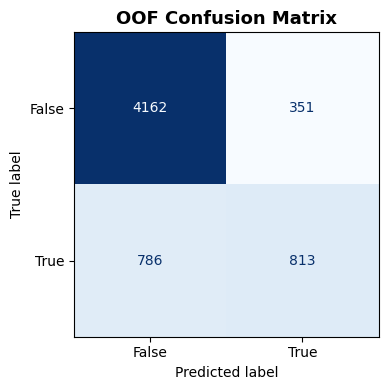


  LGBMClassifier_Method  +  LGBMRegressor_Method

----- Fold 1 / 5 -----
[CLF] AUC : 0.8306
[REG] RMSE: 13.4133 | MAE: 8.7356 | R2: 0.4530

----- Fold 2 / 5 -----
[CLF] AUC : 0.8243
[REG] RMSE: 14.1015 | MAE: 8.7206 | R2: 0.4927

----- Fold 3 / 5 -----
[CLF] AUC : 0.8479
[REG] RMSE: 15.9415 | MAE: 9.2886 | R2: 0.3407

----- Fold 4 / 5 -----
[CLF] AUC : 0.8420
[REG] RMSE: 14.0332 | MAE: 8.5801 | R2: 0.4308

----- Fold 5 / 5 -----
[CLF] AUC : 0.8390
[REG] RMSE: 10.6169 | MAE: 6.7539 | R2: 0.4567

OOF AUC      : 0.8365
Mean CV AUC  : 0.8368 ± 0.0084
Mean RMSE    : 13.6213
Mean MAE     : 8.4158
Mean R2      : 0.4348

Classification Report:
              precision    recall  f1-score   support

       False       0.88      0.83      0.85      4513
        True       0.58      0.68      0.63      1599

    accuracy                           0.79      6112
   macro avg       0.73      0.75      0.74      6112
weighted avg       0.80      0.79      0.79      6112



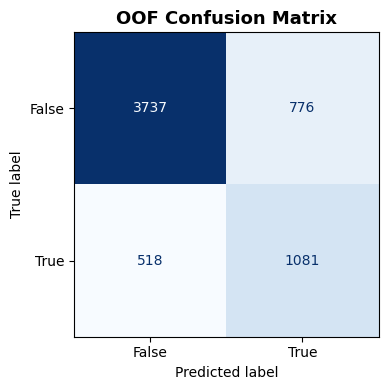


  XGBClassifier_Method  +  XGBRegressor_Method

----- Fold 1 / 5 -----
[CLF] AUC : 0.8220
[REG] RMSE: 15.3323 | MAE: 10.2865 | R2: 0.4525

----- Fold 2 / 5 -----
[CLF] AUC : 0.8203
[REG] RMSE: 17.3756 | MAE: 11.1383 | R2: 0.4566

----- Fold 3 / 5 -----
[CLF] AUC : 0.8375
[REG] RMSE: 18.6934 | MAE: 10.6901 | R2: 0.2859

----- Fold 4 / 5 -----
[CLF] AUC : 0.8308
[REG] RMSE: 15.8220 | MAE: 9.7613 | R2: 0.4920

----- Fold 5 / 5 -----
[CLF] AUC : 0.8332
[REG] RMSE: 11.2866 | MAE: 7.3967 | R2: 0.5641

OOF AUC      : 0.8286
Mean CV AUC  : 0.8288 ± 0.0066
Mean RMSE    : 15.7020
Mean MAE     : 9.8546
Mean R2      : 0.4502

Classification Report:
              precision    recall  f1-score   support

       False       0.82      0.95      0.88      4513
        True       0.72      0.41      0.52      1599

    accuracy                           0.80      6112
   macro avg       0.77      0.68      0.70      6112
weighted avg       0.79      0.80      0.78      6112



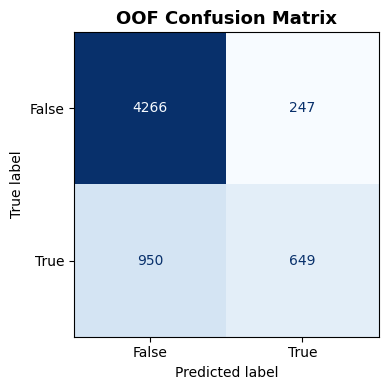

In [ ]:
# ── เรียกใช้ ─────────────────────────────────────────────────────────
all_results_method_8th = Proposed_method_together(
    feature_method,
    target_methodClassify,
    target_methodRegression,
    algo_method_8th,          # ✅ ส่ง algo_method_method เข้าไปตรงๆ
    n_splits=5
)

##

### Hyperparameter tunning

In [ ]:
rf = RandomForestRegressor(random_state=42)

param_rf = {
    "n_estimators": [200, 300, 500, 800],
    "max_depth": [10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

search_rf = RandomizedSearchCV(
    rf,
    param_rf,
    n_iter=30,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=2,
    random_state=42
)

search_rf.fit(feature_method.values, target_methodRegression.values)
print(search_rf.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
{'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 10}


In [ ]:
xgb = XGBRegressor(random_state=42, n_jobs=-1)

param_xgb = {
    "n_estimators": [300, 500, 800, 1000],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.2, 0.3]
}

search_xgb = RandomizedSearchCV(
    xgb,
    param_xgb,
    n_iter=40,
    cv=5,
    scoring="r2",
    verbose=2,
    n_jobs=-1,
    random_state=42
)

search_xgb.fit(feature_method.values, target_methodRegression.values)
print(search_xgb.best_params_)
print(search_xgb.best_score_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
{'subsample': 0.8, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0.2, 'colsample_bytree': 0.6}
0.06564990164370663


In [ ]:
lgbm = lgb.LGBMRegressor(random_state=42)

param_lgbm = {
    "n_estimators": [300, 500, 800, 1000],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "num_leaves": [15, 31, 50, 80],
    "max_depth": [-1, 5, 10, 15],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0]
}

search_lgbm = RandomizedSearchCV(
    lgbm,
    param_lgbm,
    n_iter=30,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=2,
    random_state=42
)

search_lgbm.fit(feature_method.values, target_methodRegression.values)
print(search_lgbm.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
{'subsample': 1.0, 'num_leaves': 15, 'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.03, 'colsample_bytree': 0.6}


##

##